## Training with generative adversarial networks (GANs) with einstein rings data

Because of small data (196 images), it can cause overfit very fast, memorize the training images, generate blurry or repeated samples, also unstable during training. 

Using StyleGAN2-ADA, FastGAN, DCGAN first. 

### StyleGAN2-ADA
StyleGAN2-ADA is an advanced implementation of Generative Adversarial Networks (GANs) designed to train models effectively even with limited data. 


StyleGAN2-ADA aims to enhance the training of GANs by introducing an adaptive discriminator augmentation mechanism. This approach stabilizes training in scenarios where data is scarce, allowing for effective model training with as few as a few thousand images.

- Adaptive Discriminator Augmentation: Reduces overfitting and improves training stability.
- Performance: Achieves faster training times compared to previous implementations.
- Compatibility: Supports legacy TensorFlow models and offers new dataset formats.

### 1. Import and paths

In [3]:
import os 
import shutil   
from pathlib import Path    
from PIL import Image, ImageFile 
import numpy as np 
import matplotlib.pyplot as plt
import random 
from tqdm import tqdm   

ImageFile.LOAD_TRUNCATED_IMAGES = True  

raw_dir = "../einstein_rings/einstein_rings_all"
clean_dir = "../einstein_rings/einstein_rings_cleaned"
aug_dir = Path("../einstein_rings/einstein_rings_augmented")  
zip_path = Path("../einstein_rings/einstein_rings_128.zip") # StyleGAN2-ADA-PyTorch expects a zip file as input.    

TARGET_FORMAT = "jpg"


### 2. Inspect image sizes 

In [4]:
image_paths = []
for f in Path(raw_dir).iterdir():
    if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        image_paths.append(f)

print(f"Found {len(image_paths)} images in {raw_dir}.")

sizes = []
bad_files = []

for p in tqdm(image_paths):
    try:
        with Image.open(p) as img:
            sizes.append(img.size)
    except Exception as e:
        bad_files.append((p.name, str(e)))

print(f"Readable images: {len(sizes)}")
print(f"Unreadable images: {len(bad_files)}")

if sizes:
    widths = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    print("Min size:", (min(widths), min(heights)))
    print("Max size:", (max(widths), max(heights)))

Found 195 images in ../einstein_rings/einstein_rings_all.


100%|██████████| 195/195 [00:00<00:00, 1581.90it/s]

Readable images: 195
Unreadable images: 0
Min size: (100, 100)
Max size: (100, 100)


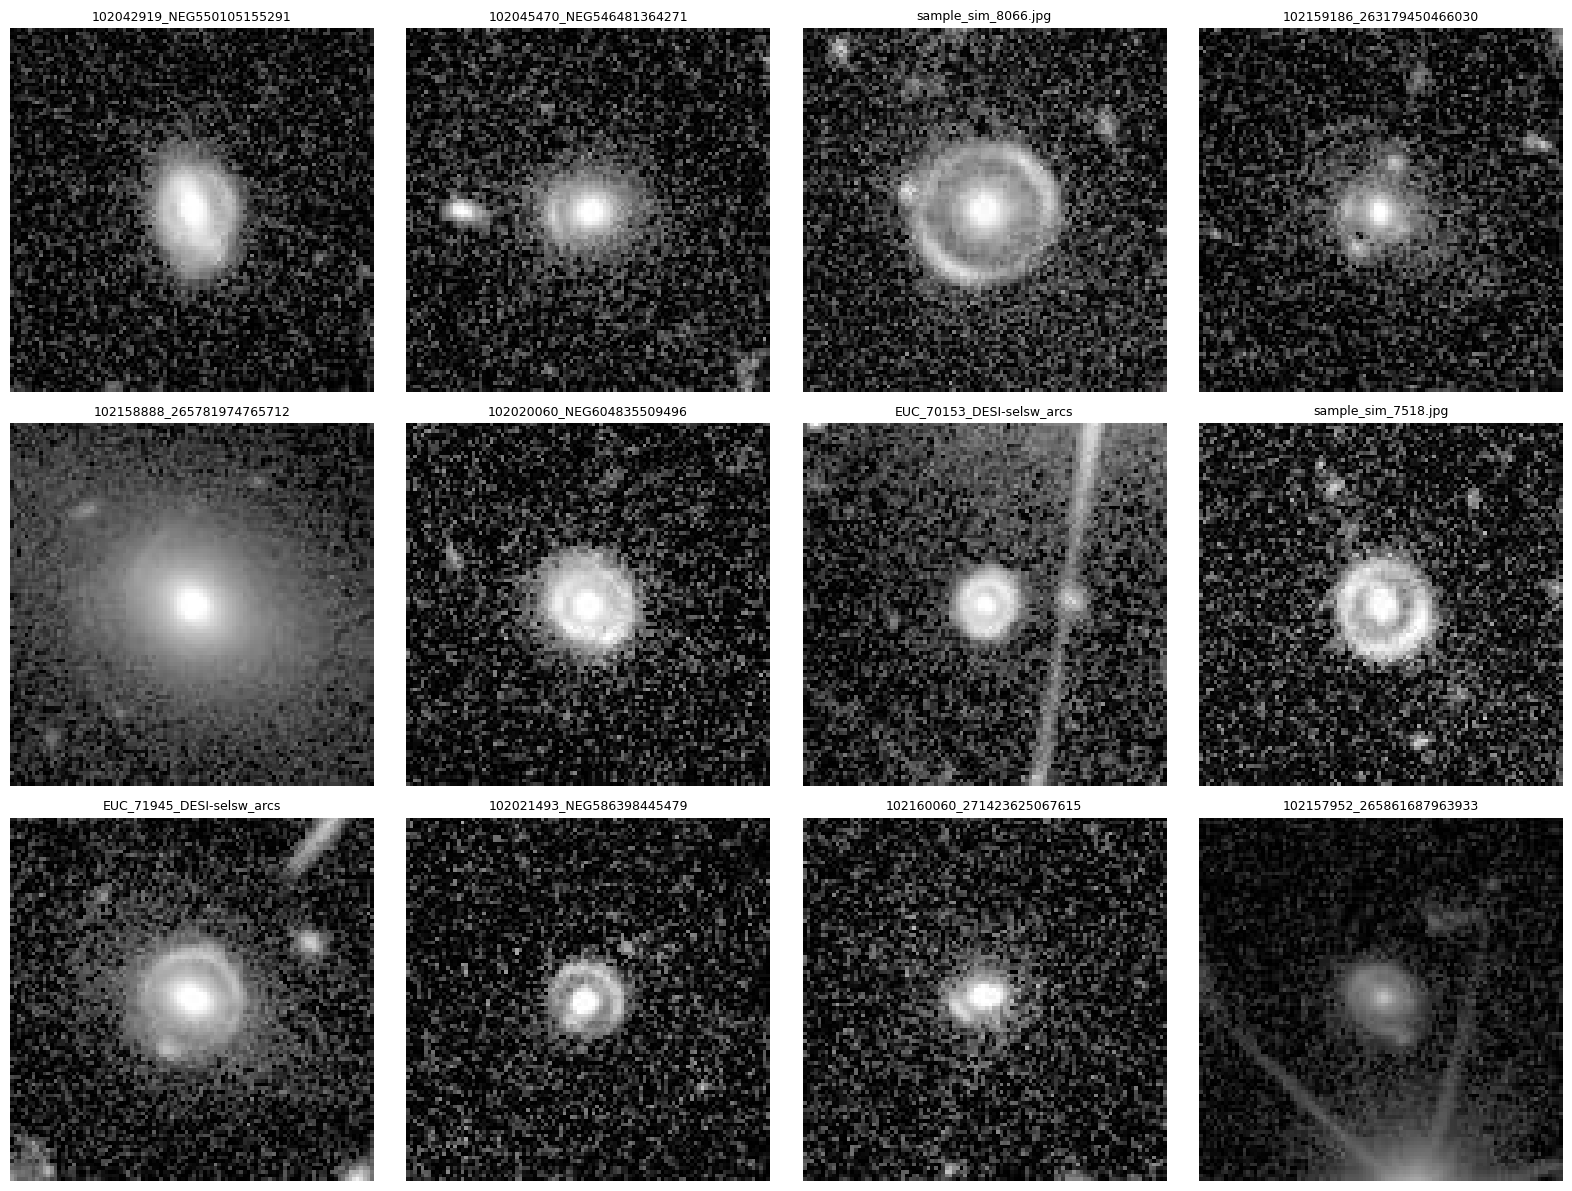

In [6]:
def show_random_images(folder, n=30, cols=4):
    files = [f for f in Path(folder).iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    files = random.sample(files, min(n, len(files)))
    
    rows = int(np.ceil(len(files) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))
    
    for i, f in enumerate(files, 1):
        img = Image.open(f)
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(f.name[:25], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_random_images(raw_dir, n=12, cols=4)

In [7]:
def load_image_as_normalized_array(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32) / 127.5 - 1.0
    return arr
sample_arr = load_image_as_normalized_array(image_paths[0]) 
print("Sample image shape:", sample_arr.shape)
print("Sample pixel range:", (sample_arr.min(), sample_arr.max()))

Sample image shape: (100, 100, 3)
Sample pixel range: (np.float32(-1.0), np.float32(1.0))


### 3. Data augmentation review 
For StyleGAN2-ADA, augmentation is usually handled during training automatically by ADA.

Converting to RGB format because it contains 3 channels, standard color image. It standard in deep learning, uses most pretrained models (eg in torchvision)

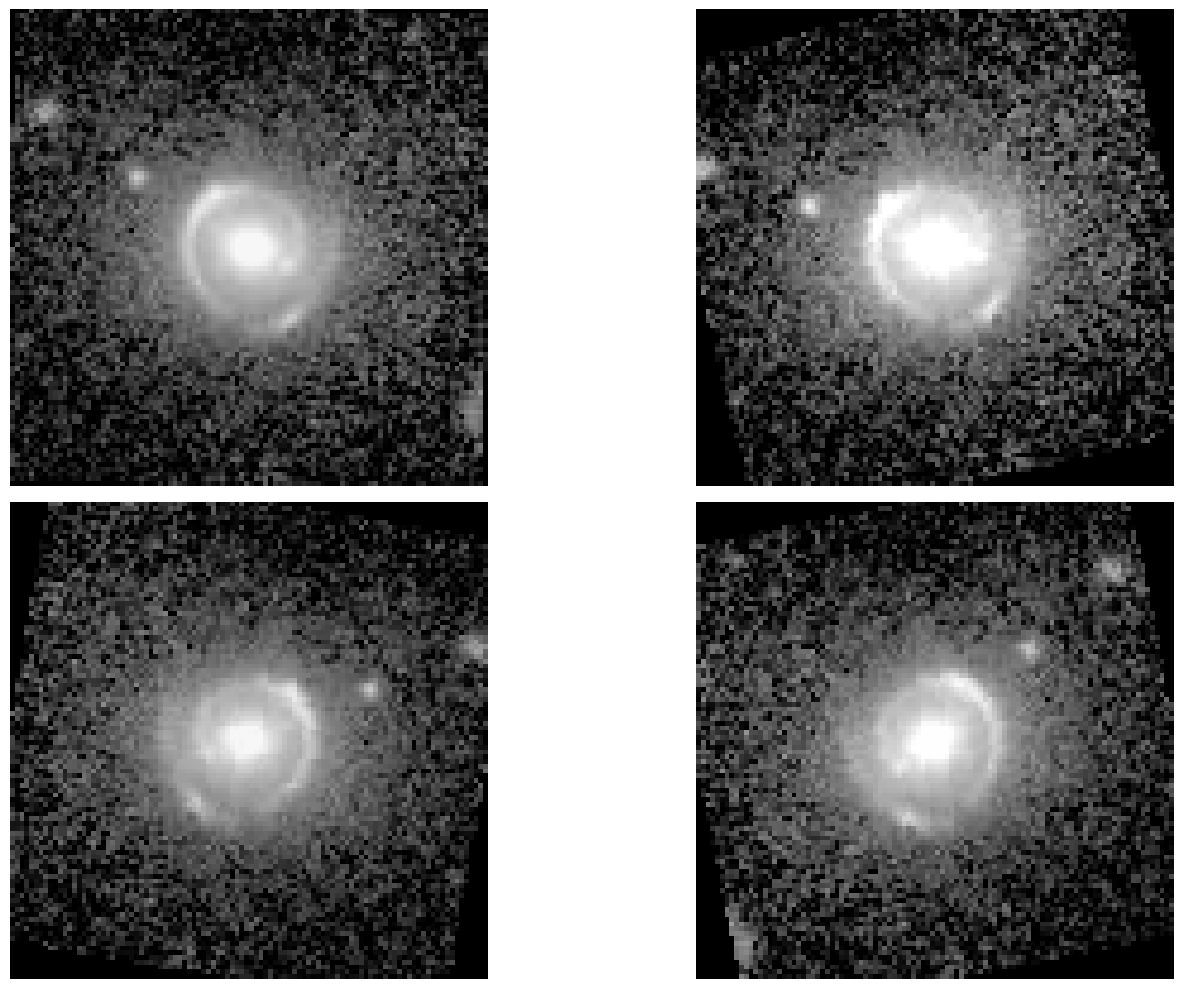

In [19]:
import torchvision.transforms as transforms 

preview_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomVerticalFlip(p=0.2), # flip image up-down
    transforms.RandomRotation(degrees=15), # rotate image randomly between -15 and 15 degrees   
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # slightly changes brightness and contrast
])

# n: number of augmented samples to generate 
def show_augmentations(img_path, n=4):
    img = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(16, 10))
    for i in range(n):
        aug = preview_transform(img)
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(aug)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_augmentations(image_paths[10], n=4)

In [31]:
def save_augmented_preview(files, output_dir, n_per_image=4):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    count = 0
    for f in tqdm(files):
        img = Image.open(f).convert("RGB")
        for i in range(n_per_image):
            aug = preview_transform(img)
            out_path = output_dir / f"{f.stem}_aug{i}.png"
            aug.save(out_path)
            count += 1
    return count

num_saved = save_augmented_preview(image_paths, aug_dir, n_per_image=4)
print("Saved augmented preview images:", num_saved)

100%|██████████| 195/195 [00:04<00:00, 39.41it/s]

Saved augmented preview images: 780


In [32]:
# for f in aug_dir.glob("*.png"):
#     f.unlink()  # delete the file
num_images = len(list(Path(aug_dir).glob("*.png")))
print(f"Total augmented images in {aug_dir}: {num_images}") 

Total augmented images in ..\einstein_rings\einstein_rings_augmented: 780


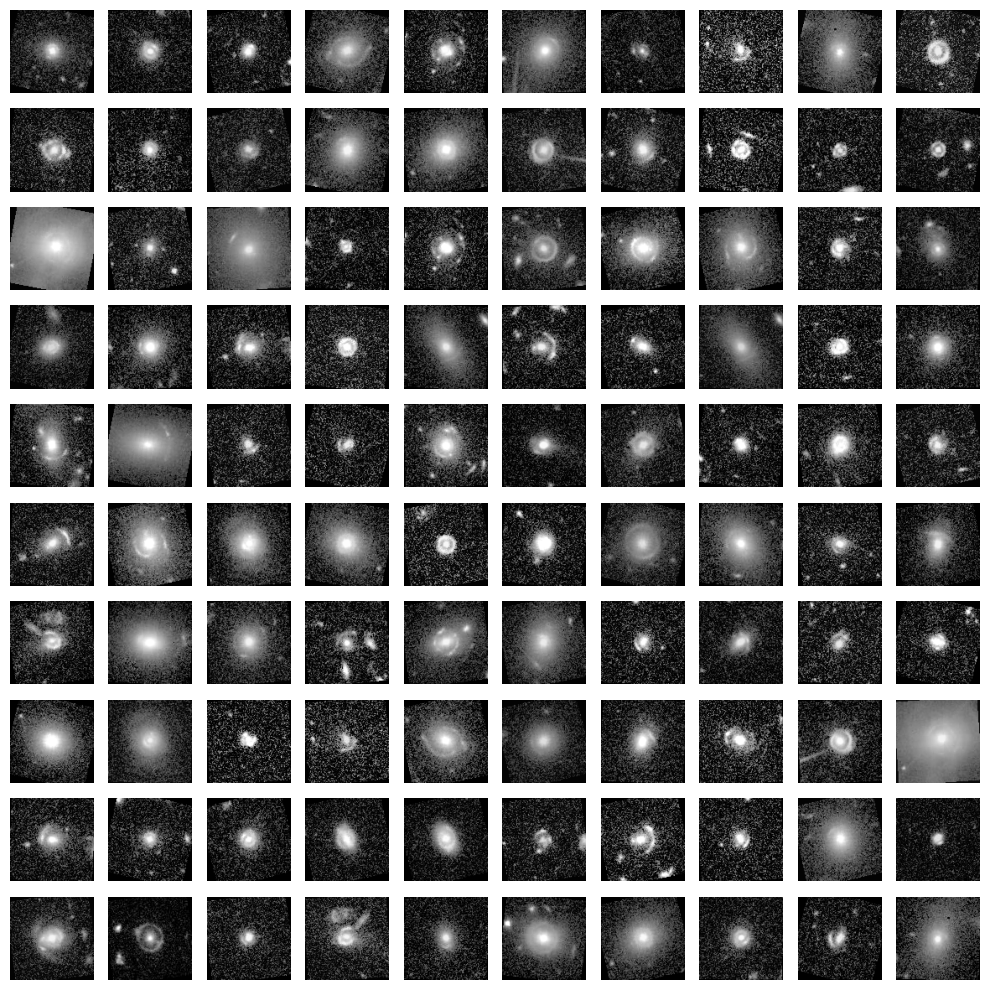

In [33]:
images = os.listdir(aug_dir)
sample = random.sample(images, 100)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(sample):
    img = Image.open(os.path.join(aug_dir, img_name))

    plt.subplot(10,10,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4. ZIP dataset for StyleGAN2-ADA

In [36]:
# Cell 10
import zipfile

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_STORED) as zf:
    for f in tqdm(image_paths):
        zf.write(f, arcname=f.name)
    print(len(image_paths), "images added to zip.")

print("Saved zip dataset to:", zip_path)

100%|██████████| 195/195 [00:00<00:00, 779.68it/s]

195 images added to zip.
Saved zip dataset to: ..\einstein_rings\einstein_rings_128.zip


### 5. Train/validation split

In [37]:
from sklearn.model_selection import train_test_split  


train_files, val_files = train_test_split(image_paths, test_size=0.2, random_state=42)
print(f"Training set: {len(train_files)} images")
print(f"Validation set: {len(val_files)} images")

# all_files = [f for f in Path(raw_dir).iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
# train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)
# print(f"Training set: {len(train_files)} images")
# print(f"Validation set: {len(val_files)} images")



Training set: 156 images
Validation set: 39 images


### 6. StyleGAN2-ADA
Now I used 195 original images for trainning StyleGAN2-ADA. Because StyleGAN2-ADA already applies augmentation adaptively during training. 

- Experiment A: train StyleGAN2-ADA on the 195 original images only.
- Experiment B: only if A is clearly too weak, test a second run with a carefully filtered augmented set.


#### 6.1. Clone from git

In [38]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

fatal: destination path 'stylegan2-ada-pytorch' already exists and is not an empty directory.


In [ ]:
cd stylegan2-ada-pytorch

c:\Users\nguye\OneDrive\Desktop\uni\Y2_Sem4\Euclid\Euclid_GenerateImages\Euclid_DeltaProject\notebook\stylegan2-ada-pytorch


: 

: 

: 

#### 6.2. Train StyleGAN2-ADA

In [ ]:
!python train.py \
  --outdir=../training-runs \
  --data=..einstein_rings/einstein_rings_128.zip \
  --gpus=1 \
  --cfg=auto \
  --snap=5 \
  --batch=4 \
  --mirror=1

Usage: train.py [OPTIONS]

Try 'train.py --help' for help.



Error: --data: [Errno 2] No such file or directory: '..einstein_rings/einstein_rings_128.zip'



: 

: 

: 